# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

--- 

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [ ]:
NAME(s) = "Olivia Teng, Ali Powell, Will Sutton"

## 1. Paper reflection (10 points)

a. After reading the introduction of the paper, discuss within the group and address the following questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

Please, elaborate on your answers.

Predicting seismic building response is important as earthquake effects from the ground shaking can include severe damage to buildings, leading to injuries, deaths, property damage, loss of infrastructure, economic losses, and functional loss. Damages from earthquakes cause expensive and long repairs. Human safety is also at risk during earthquakes, especially depending on building structures. Lots of buildings in cities have design information that is missing or not complete, so emergency response planning is not adequately safe or thorough. Predicting the building response can help emergency responders find the buildings that would require attention first, and economic losses can be estimated to help decisions about where emergency resources and protocols should be allocated.


The dataset of this study is particularly well-suited for a machine learning approach as it includes many entries of data that include real earthquake observations. The data includes structural information about buildings, like building height, the number of stories, and it includes earthquake information like duration, magnitude, peak ground velocity, and peak ground distance. The thoroughness, variety of features, and amount of entries are very well-suited for machine learning because it allows for exploration of the many variables that may affect the prediction outcome. Machine learning can use all these features together to create a better prediction. Traditional physics-based methods may not be able to handle so many variables at the same time. Further, they may not be able to capture non-linear relationships as well as machine learning. Machine learning can use multiple dimensions to learn from data.

Support Vector Regression works by finding a regression function that is as flat as possible, but allowing predictions to fall within an acceptable error range. It can find a regression function that is nonlinear with multiple variables.

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

1. The first formula shows the regression function, showing the multiple inputs used and transforming them into a feature space. w represents the weights, epsilon is the permitted error, and b is the intercept. In class, we saw how the SVM used an equation like this to see what side of a decision boundary a certain observation is on. In SVR, the formula gives a continuous numerical prediction.


2. This formula shows how SVR tries to make the regression function as flat as possible. We see the minimization of the error between the predicted and true value.


3. Here, we see tolerance allowed for the errors. We see that if errors are small enough, smaller than epsilon which is what is allowed, they are ignored.


4. This is where SVR optimizes the minimization of the loss function. This formula makes a flat function and this is where slack variables can measure how far an observation is on either side to control the penalization of observations that are outside of the epsilon.


5. This is the condition for the previous formula.This is what decides if a point is inside or outside, essentially determining the boundaries. The first line correlates to observations below the regression function, and the second line correlates to observations above the regression function.


6. This is the Langrangian function. This is where optimization with constraints is done and the model can be trained.

7. Equation 7 is essentially building the model from influential data points- its saying to multiply each transformed training point by its influence, then add them together to get the model's weights. The points with non-zero vectors are support vectors which determine the fit.

8. This equation balances the signed influences- The positive/negative coefficients must balance overall, and this condition comes from optimizing the model's intercept b which shifts the prediction up or down. It doesn't mean even numbers of points above and below, it's just that their total coefficient weights must balance.

9. This equation is limiting any one point's influence. The \(\gamma\)'s are non negative helper variables from the optimization. Because these variables and ai, Bi, aren't negative, this implies that \[
0\leq\alpha_i\leq C,\qquad 0\leq\beta_i\leq C\] - so C caps how much influence each point can have. A larger C would make errors outside the tube more costly and encourage a tighter fit, while a smaller C allows more error in exchange for a flatter more regularized fit.

10. This equation finds the intercept b. It's basically asking how much we should shift the fitted function up or down so that this support vector sits on the tube's edge. It's taking the points actual value yi, subtracting the model's output before adding an intercept, and then adding \(\epsilon\). The two expressions are set equal to each other because they are performing the same calculation, the first one using weights W, and the second half writing those weights in terms of training points and kernel. 

11. This equation is using that b from before to predict an output. It's trying to figure out, for input xj, what value to predict. It compares xj with the support vectors through the kernel then multiplies each comparison by its learned influence then adds everything together, and adds b.

## 2. Exploratory Analysis (15 Points)

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [5]:
# [Your code here]
import pandas as pd
import numpy as np

df = pd.read_excel('data_lab02.xlsx', header=1)
df.head()
df = df.iloc[1:].reset_index(drop=True)

columns_to_drop = ['Network', 'Building ID', 'Soil info.', 'Vs30', 'Typology', 'Event Date', 'PTA', 'PTV', 'PTD']
df = df.drop(columns=columns_to_drop)
df.head()



,B_Lat.,B_Long.,Height,No. of story,E_Lat.,E_Long.,Magnitude,Epicentral distance (R),PGA,PGV,...,Uniform [0.15g],Bracketed [0.2g],Uniform [0.2g],Significant_a1 [(5-75)%],Significant_a2 [(5-95)%],Significant_v1 [(5-75)%],Significant_v2 [(5-95)%],Significant_d1 [(5-75)%],Significant_d2 [(5-95)%],ZX
0,36.132,140.073,3400,8,34.03,136.2283,5.3,420.7,1.577005,0.073452,...,0,0,0,54.89,73.15,56.97,81.65,93.23,122.2,54.300537
1,36.132,140.073,3400,8,36.1067,139.8917,3.8,16.6,3.449968,0.132411,...,0,0,0,5.96,19.57,13.88,27.74,25.26,63.18,6.934593
2,36.132,140.073,3400,8,37.02,141.0583,4.2,132.2,0.854165,0.036735,...,0,0,0,10.6,29.11,18.58,48.81,70.65,72.53,5.923775
3,36.132,140.073,3400,8,36.045,140.0867,3.4,9.8,0.549761,0.026009,...,0,0,0,10.45,25.24,13.61,32.37,33.76,57.79,5.139623
4,36.132,140.073,3400,8,35.46,140.7517,5.7,96.6,5.863478,1.006804,...,0,0,0,24.25,48.01,23.06,50.12,28.47,70.65,20.686939


b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

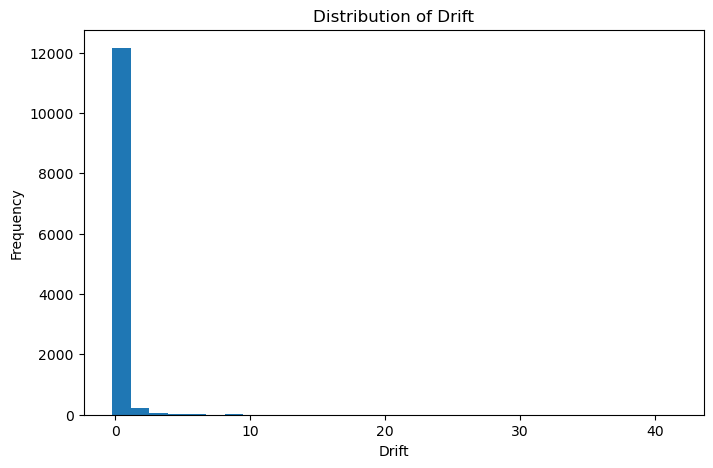

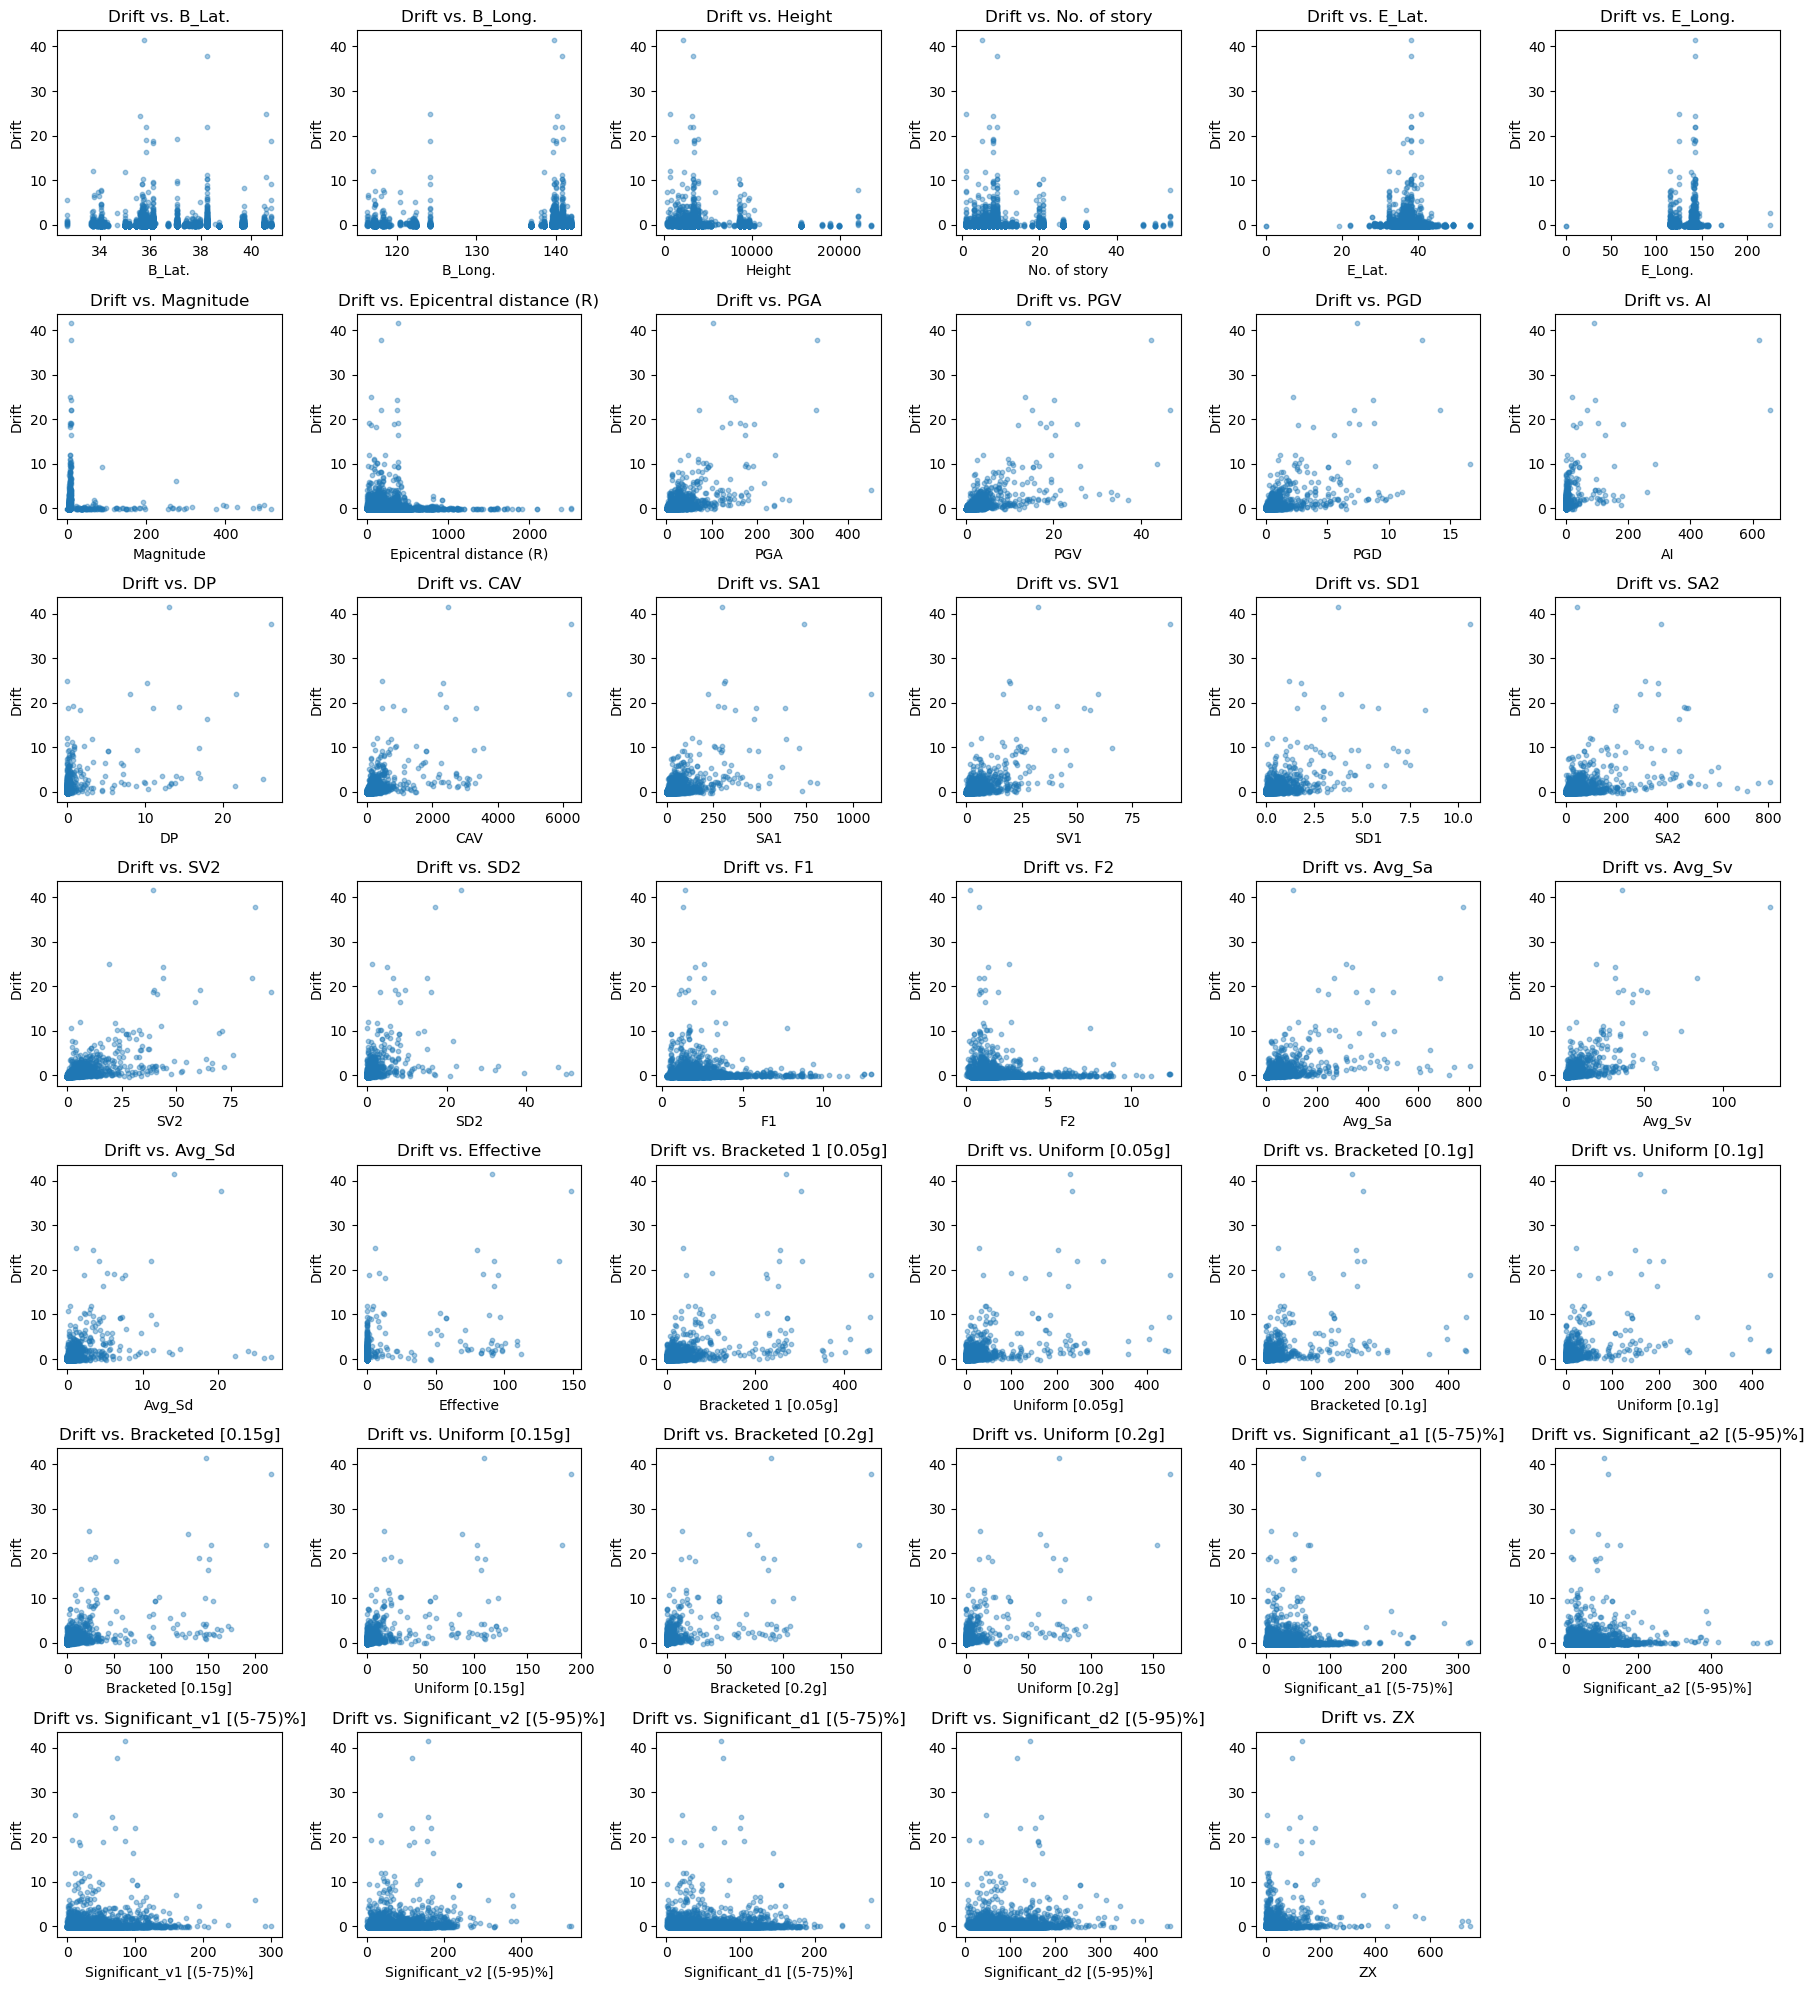

In [6]:
# [Your code here]
import matplotlib.pyplot as plt

df = df.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8, 5))
plt.hist(df['Drift'], bins=30)
plt.xlabel('Drift')
plt.ylabel('Frequency')
plt.title('Distribution of Drift')
plt.show()

features = df.columns.drop('Drift')
fig, axes = plt.subplots(7, 6, figsize=(18, 20))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Drift'], alpha=0.4, s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Drift')
    axes[i].set_title(f'Drift vs. {feature}')

for i in range(len(features), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?

The distribution for Drift is extremely rightly skewed, with most observations concentrated near zero. From the scatterplots, some of the ground-motion and spectral variables appear to have stronger relationships with Drift than variables like building or epicenter location. PGV, SV1, SV2, Avg_Sv, SD1, PGD, and CAV display the clearest positive relationships wtih Drift. Overall, the plots demonstrate that several different features may contribute to predicting Drift rather than there being one clearly dominant predictor.

## 3. Fit and evaluate (30 points)

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop(columns='Drift')
y = df['Drift']

# Separate reporting set for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svr_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('svr', SVR())])
svr_params = {'svr__kernel': ['linear', 'rbf'], 'svr__C': [0.1, 1, 10]}
svr_grid = GridSearchCV(svr_pipeline, svr_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
svr_grid.fit(X_train, y_train)
svr_pred = svr_grid.predict(X_test)
svr_r2 = r2_score(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)

print("Best parameters:", svr_grid.best_params_)
print("SVR R²:", svr_r2)
print("SVR MSE:", svr_mse)

Best parameters: {'svr__C': 0.1, 'svr__kernel': 'linear'}
SVR R²: 0.5191177972231351
SVR MSE: 0.48302832151963265


b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [8]:
# [Your code here]
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('ridge', Ridge())])
ridge_params = {'ridge__alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
ridge_pred = ridge_grid.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)

print("Best alpha:", ridge_grid.best_params_)
print("Ridge R²:", ridge_r2)
print("Ridge MSE:", ridge_mse)

Best alpha: {'ridge__alpha': 100}
Ridge R²: 0.5596940153755059
Ridge MSE: 0.44227101664418367


c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

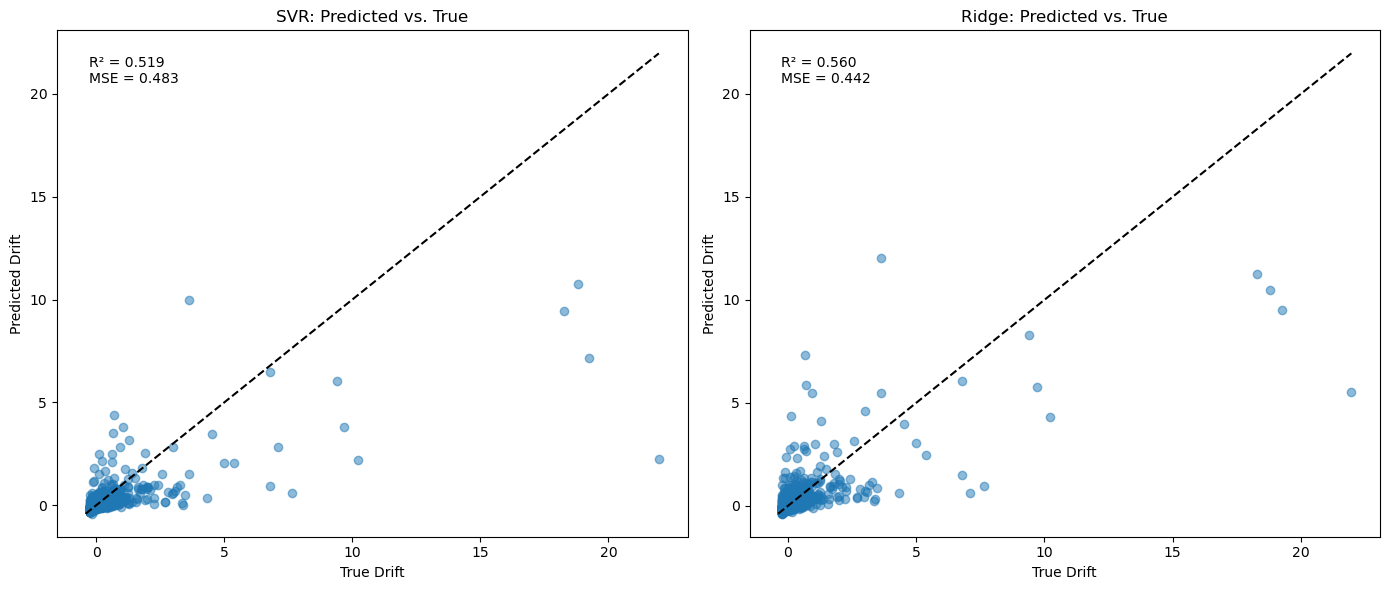

In [9]:
# [Your code here]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SVR
axes[0].scatter(y_test, svr_pred, alpha=0.5)
min_val = min(y_test.min(), svr_pred.min())
max_val = max(y_test.max(), svr_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--')
axes[0].set_xlabel('True Drift')
axes[0].set_ylabel('Predicted Drift')
axes[0].set_title('SVR: Predicted vs. True')
axes[0].text(0.05, 0.95, f'R² = {svr_r2:.3f}\nMSE = {svr_mse:.3f}', transform=axes[0].transAxes, verticalalignment='top')

# Ridge
axes[1].scatter(y_test, ridge_pred, alpha=0.5)
min_val = min(y_test.min(), ridge_pred.min())
max_val = max(y_test.max(), ridge_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--')
axes[1].set_xlabel('True Drift')
axes[1].set_ylabel('Predicted Drift')
axes[1].set_title('Ridge: Predicted vs. True')
axes[1].text(0.05, 0.95, f'R² = {ridge_r2:.3f}\nMSE = {ridge_mse:.3f}', transform=axes[1].transAxes, verticalalignment='top')

plt.tight_layout()
plt.show()

The Ridge regression framework appears to perform slightly better than the SVR framework on the reporting set. Ridge achieved a higher R^2 of 0.560 in comparison to 0.519 for SVR, while also producing a lower MSE of 0.442 compared to 0.483. The predicted vs. true plots also show that both models struggle more with some of the larger Drift values, but overall Ridge provides slightly better predictive performance. 

## 4. Reduced SVR Model (30 points)

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [10]:
from sklearn.feature_selection import SelectKBest, f_regression

# f_regression
svr_k_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_regression, k=10)),
    ('svr', SVR())
])
svr_k_grid = GridSearchCV(svr_k_pipe, svr_params, cv=3,
                          scoring='neg_mean_squared_error', n_jobs=-1)
svr_k_grid.fit(X_train, y_train)

svr_k_pred = svr_k_grid.predict(X_test)
svr_k_r2 = r2_score(y_test, svr_k_pred)
svr_k_mse = mean_squared_error(y_test, svr_k_pred)

mask = svr_k_grid.best_estimator_.named_steps['select'].get_support()
svr_k_features = list(X_train.columns[mask])

print("Best params:", svr_k_grid.best_params_)
print("Selected features:", svr_k_features)
print(f"Reduced SVR  R²: {svr_k_r2:.3f}  MSE: {svr_k_mse:.3f}")
print(f"Full SVR     R²: {svr_r2:.3f}  MSE: {svr_mse:.3f}")
print(f"Change in R²: {svr_k_r2 - svr_r2:+.3f}   Change in MSE: {svr_k_mse - svr_mse:+.3f}")

Best params: {'svr__C': 10, 'svr__kernel': 'linear'}
Selected features: ['PGA', 'PGV', 'PGD', 'CAV', 'SA1', 'SV1', 'SD1', 'SV2', 'Avg_Sv', 'Uniform [0.2g]']
Reduced SVR  R²: 0.492  MSE: 0.511
Full SVR     R²: 0.519  MSE: 0.483
Change in R²: -0.028   Change in MSE: +0.028


Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

Elaborate on your answers.

By only using the 10 features that are the most correlated with drift, R^2 changed from 0.519 to 0.492, which is a small change. This can suggest that a lot of the prediction relies on a smaller set of the ground motion variables like PGV, SV1, SV2, SD1, PGD, as the rest of the features are more correlated with each other, which makes adding them redundant to the prediction and do not add much value to the prediction. Practical advantages of using this predictive framework with a smaller subset of features can be that it would make training and prediction faster as the model would have to work with less features. More data can be used or data collection can be cheaper as the article mentioned a lot of buildings had incomplete data. But, if we can predict pretty well with this subset, we can be more confident in using what may be considered incomplete data. Additionally, this can help with less overfitting as we focus on features that are relevant and not redundant. 

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

In [15]:
from sklearn.linear_model import Lasso

lasso = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=50000))
])
lasso_params = {'lasso__alpha': np.logspace(-4, 1, 20)}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5,
                          scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train, y_train)

lasso_pred = lasso_grid.predict(X_test)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)

coefs = lasso_grid.best_estimator_.named_steps['lasso'].coef_
lasso_features = list(X_train.columns[coefs != 0])

print("Best alpha:", lasso_grid.best_params_)
print(f"Lasso features: {lasso_features}")
print(f"Reduced SVR (top 10)  R²: {svr_k_r2:.3f}  MSE: {svr_k_mse:.3f}")
print(f"Lasso  R²: {lasso_r2:.3f}  MSE: {lasso_mse:.3f}")
print("\nLasso kept", len(lasso_features), "features:", lasso_features)
print("Shared with SVR top 10:", sorted(set(lasso_features) & set(svr_k_features)))
print("Only in SVR top 10:", sorted(set(svr_k_features) - set(lasso_features)))
print("Only in Lasso:", sorted(set(lasso_features) - set(svr_k_features)))

Best alpha: {'lasso__alpha': 0.04281332398719392}
Lasso features: ['B_Long.', 'PGD', 'AI', 'DP', 'SV1', 'SD1', 'Avg_Sv']
Reduced SVR (top 10)  R²: 0.492  MSE: 0.511
Lasso  R²: 0.583  MSE: 0.419

Lasso kept 7 features: ['B_Long.', 'PGD', 'AI', 'DP', 'SV1', 'SD1', 'Avg_Sv']
Shared with SVR top 10: ['Avg_Sv', 'PGD', 'SD1', 'SV1']
Only in SVR top 10: ['CAV', 'PGA', 'PGV', 'SA1', 'SV2', 'Uniform [0.2g]']
Only in Lasso: ['AI', 'B_Long.', 'DP']


No. Lasso kept 7 features and left out CAV, PGA, SA1, SV2, and Uniform. It also had 3 that the SVR did not have: AI, B_Long, and DP. The lasso performed much better, with an R^2 of 0.583 and an MSE of 0.419. 

## 5: Robustness to Point Removal (10 points)

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

In [ ]:
# [Your code here]

## 6. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE